In [1]:
from tqdm.auto import tqdm

from rush_hour_lib import (
    Environment, Agent, Train, Teacher, plot_training_results, average_histories,
    DQNAgent, DQNTrain, sample_puzzle
)

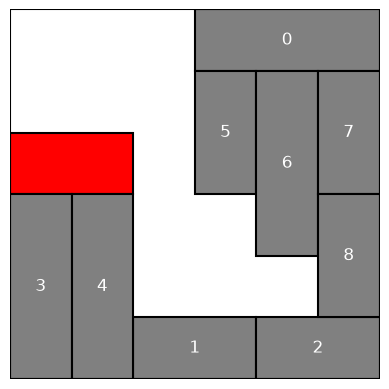

In [6]:
puzzle = sample_puzzle()
puzzle1 = Environment((6, 6), puzzle)
puzzle1.visualize()


## DQN agent

Reuses the same `Environment`, action space, and reward scheme as the tabular
`Agent`/`Train`, so the two can be trained on the same puzzle and compared with
`plot_training_results`. Differences from the tabular setup:

- **State encoding**: instead of using the raw state tuple as a dict key, each
  block's anchor `(row, col)` is normalized into a fixed-size vector fed to a
  small MLP.
- **Action masking**: at every step the set of currently-legal `(block, direction)`
  moves is computed directly (by trying and undoing each move on the live
  environment) and used to mask both action selection and the target-network
  max, so the agent never wastes a step on an illegal move the way the tabular
  agent's `_prune` mechanism implicitly did during exploration.
- **Learning**: standard DQN — replay buffer, soft (Polyak-averaged)
  target network update each step via `tau`, Huber loss.


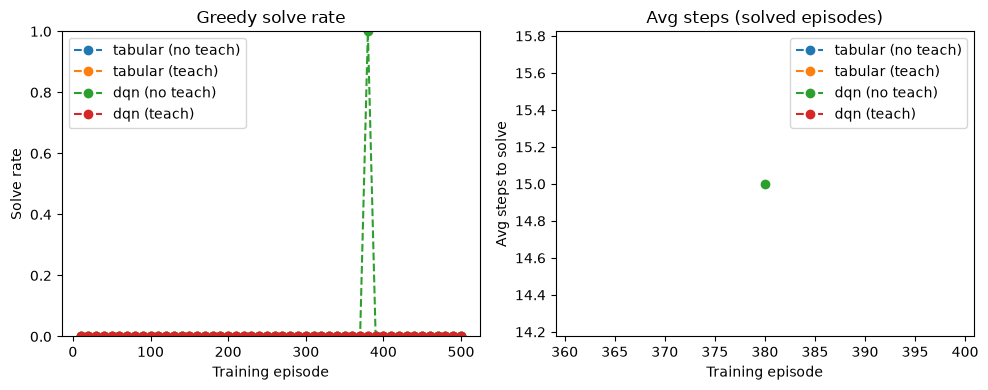

In [3]:
trainer_no_teach = Train(Agent(puzzle1.blocks), puzzle1)
trainer_no_teach.learn(500, eval_every=10)

trainer_teach = Train(Agent(puzzle1.blocks), puzzle1)
trainer_teach.learn(500, eval_every=10, teach_every=25, policy="random", max_hints=3)

dqn_trainer = DQNTrain(DQNAgent(puzzle1.blocks), puzzle1)
dqn_trainer.learn(500, eval_every=10)

dqn_trainer_teach = DQNTrain(DQNAgent(puzzle1.blocks), puzzle1)
dqn_trainer_teach.learn(500, eval_every=10, teach_every=25, policy="random", max_hints=3)

plot_training_results({
    "tabular (no teach)": trainer_no_teach.history,
    "tabular (teach)": trainer_teach.history,
    "dqn (no teach)": dqn_trainer.history,
    "dqn (teach)": dqn_trainer_teach.history,
}, "agent_comparison.png")

## Learned ("q") teaching policy

`Teacher(policy="q")` replaces the fixed `hint_prob` coin flip with a tiny tabular
Q-learner: state is distance-to-goal alone, action is hint-or-not, and the
reward is the student's own per-step reward, bootstrapped one step at a time
(same update rule as `Agent.q_learning`).

Averaging the `q teach` condition's history directly across its student
agents (the way `no teach`/`stochastic teach` can, since they carry no state
between agents) confounds each x-axis point: an early-index agent sees a
still-mostly-random teacher while a late-index agent sees an almost fully
greedy one, since the teacher's epsilon only decays across its whole training
history. So instead the cell below first lets `q_teacher` train — teaching and
learning — across `n_train` throwaway student generations, then calls
`freeze()` to fix its Q-table and epsilon, and only *then* evaluates that
one fixed policy across the `n_agents` student generations used for the
actual comparison, exactly like `no teach`/`stochastic teach` are. Their
histories are averaged into one curve per condition to smooth out per-run
noise. Episode count is scaled down to keep this quick.

Training q_teacher:   0%|          | 0/10 [00:00<?, ?it/s]

Comparing teaching conditions:   0%|          | 0/10 [00:00<?, ?it/s]

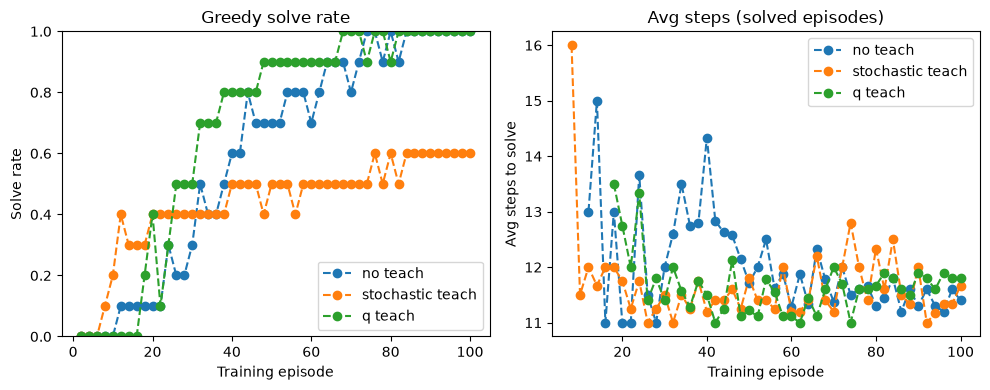

In [4]:
n_train = 10
n_agents = 10
n_episodes = 100
eval_every = 2
max_steps = 60
teach_every = 2
max_hints = 3

_scratch = DQNTrain(DQNAgent(puzzle1.blocks), puzzle1)
q_teacher = Teacher(_scratch.blocks, _scratch.solution, mode="automatic", policy="q", max_hints=max_hints)

for _ in tqdm(range(n_train), desc="Training q_teacher"):
    warmup = DQNTrain(DQNAgent(puzzle1.blocks), puzzle1)
    warmup.learn(n_episodes, eval_every=eval_every, max_steps=max_steps,
                 teach_every=teach_every, teacher=q_teacher)

q_teacher.freeze()

no_teach_histories = []
stochastic_teach_histories = []
q_teach_histories = []

for _ in tqdm(range(n_agents), desc="Comparing teaching conditions"):
    no_teach = DQNTrain(DQNAgent(puzzle1.blocks), puzzle1)
    no_teach.learn(n_episodes, eval_every=eval_every, max_steps=max_steps)
    no_teach_histories.append(no_teach.history)

    stochastic_teach = DQNTrain(DQNAgent(puzzle1.blocks), puzzle1)
    stochastic_teach.learn(n_episodes, eval_every=eval_every, max_steps=max_steps,
                            teach_every=teach_every, policy="random", max_hints=max_hints)
    stochastic_teach_histories.append(stochastic_teach.history)

    q_teach = DQNTrain(DQNAgent(puzzle1.blocks), puzzle1)
    q_teach.learn(n_episodes, eval_every=eval_every, max_steps=max_steps,
                  teach_every=teach_every, teacher=q_teacher)
    q_teach_histories.append(q_teach.history)

plot_training_results({
    "no teach": average_histories(no_teach_histories),
    "stochastic teach": average_histories(stochastic_teach_histories),
    "q teach": average_histories(q_teach_histories),
}, "teaching_comparison.png")